# 01 — Exploratory Data Analysis (Milestone 0)

**Goal:** before any modeling, understand the data and the target. This mirrors
interview Section 2 ("What exploratory analysis would you perform first?"). EDA is
graded loosely here — the point is the *habit*: look before you model.

Prereqs: `make data` (download Olist) and `make features` (or at least `load_raw` +
`build_base_table`). Work through the TODOs; write a short markdown takeaway under
each one — articulating findings is the interview skill.

Questions to answer in this notebook:
1. What does one row mean, and how many do we have after joining?
2. How is the target (`is_underperforming`) distributed — how imbalanced?
3. Which raw signals separate under- vs healthy performers?
4. What data-quality problems exist (missingness, outliers, cold-start products)?
5. What leakage risks should we watch for when we build features?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from app.config import get_settings
from app.data.load import load_raw, build_base_table

settings = get_settings()
raw = load_raw(settings.raw_dir)
{k: v.shape for k, v in raw.items()}

{'orders': (99441, 8),
 'items': (112650, 7),
 'products': (32951, 9),
 'reviews': (99224, 7),
 'customers': (99441, 5),
 'sellers': (3095, 4),
 'category_translation': (71, 2)}

In [2]:
base = build_base_table(raw)
print(base.shape)
base.info()

(110197, 26)
<class 'pandas.DataFrame'>
RangeIndex: 110197 entries, 0 to 110196
Data columns (total 26 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       110197 non-null  str           
 1   order_item_id                  110197 non-null  int64         
 2   product_id                     110197 non-null  str           
 3   seller_id                      110197 non-null  str           
 4   shipping_limit_date            110197 non-null  datetime64[us]
 5   price                          110197 non-null  float64       
 6   freight_value                  110197 non-null  float64       
 7   customer_id                    110197 non-null  str           
 8   order_status                   110197 non-null  str           
 9   order_purchase_timestamp       110197 non-null  datetime64[us]
 10  order_approved_at              110182 non-null  datetime64[us]
 11

## TODO 1 — Univariate look
Plot the distributions of `price`, `review_score`, `delivery_days`, and the count
of orders per product. Note the skew (most products sell very little — the
cold-start reality). Write one sentence on what each tells you.

### 1. Orders per product (cold-start reality)

Most products have very few orders — a power-law distribution typical of e-commerce.
This is why Bayesian smoothing matters in feature engineering: aggregates from 1–2 orders are not reliable.
Use a log y-axis; otherwise the long tail is invisible.

count    32216.000000
mean         3.420567
std         10.584388
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max        520.000000
dtype: float64


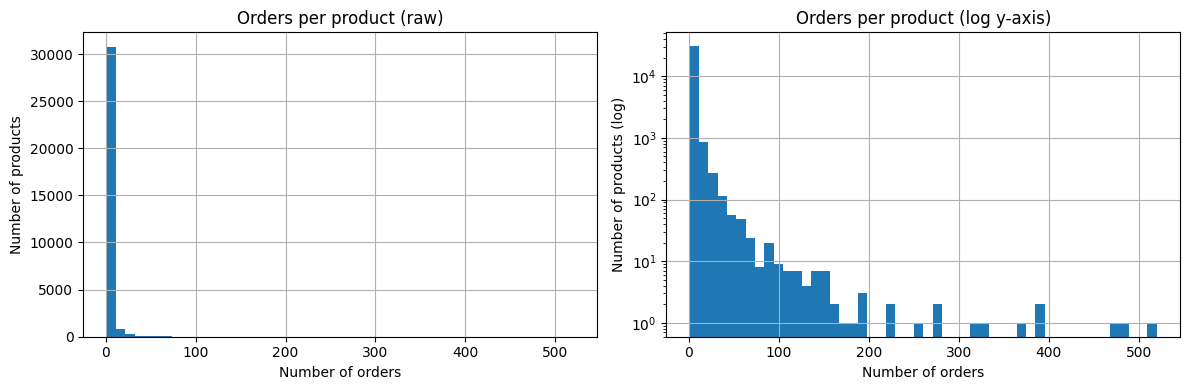


Products with only 1 order: 17716 (55.0%)
Products with < 5 orders:   27485 (85.3%)


In [3]:
orders_per_product = base.groupby('product_id').size()
print(orders_per_product.describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

orders_per_product.hist(bins=50, ax=axes[0])
axes[0].set_title('Orders per product (raw)')
axes[0].set_xlabel('Number of orders')
axes[0].set_ylabel('Number of products')

orders_per_product.hist(bins=50, log=True, ax=axes[1])
axes[1].set_title('Orders per product (log y-axis)')
axes[1].set_xlabel('Number of orders')
axes[1].set_ylabel('Number of products (log)')

plt.tight_layout()
plt.show()

print(f"\nProducts with only 1 order: {(orders_per_product == 1).sum()} ({(orders_per_product == 1).mean():.1%})")
print(f"Products with < 5 orders:   {(orders_per_product < 5).sum()} ({(orders_per_product < 5).mean():.1%})")

### 2. Price distribution

Price per transaction. Expected to be heavily right-skewed — most items are cheap, a few expensive products pull up the mean.
A log transform is typically needed before feeding this into a model.

count    110197.000000
mean        119.980563
std         182.299446
min           0.850000
25%          39.900000
50%          74.900000
75%         134.170000
90%         228.942000
95%         349.000000
99%         887.076000
max        6735.000000
Name: price, dtype: float64


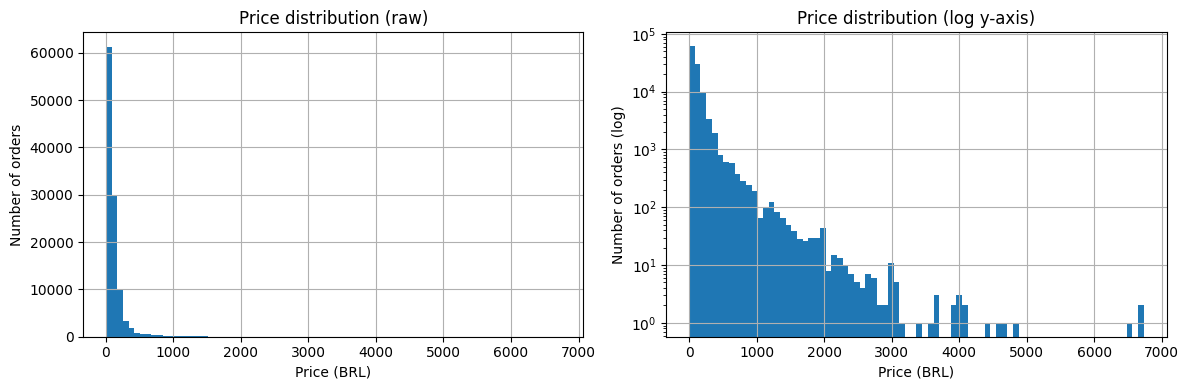


>1000 BRL: 812 (0.7%)


In [4]:
price = base['price'].dropna()
print(price.describe(percentiles=[.25, .5, .75, .9, .95, .99]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

price.hist(bins=80, ax=axes[0])
axes[0].set_title('Price distribution (raw)')
axes[0].set_xlabel('Price (BRL)')
axes[0].set_ylabel('Number of orders')

price.hist(bins=80, log=True, ax=axes[1])
axes[1].set_title('Price distribution (log y-axis)')
axes[1].set_xlabel('Price (BRL)')
axes[1].set_ylabel('Number of orders (log)')

plt.tight_layout()
plt.show()

print(f"\n>1000 BRL: {(price > 1000).sum()} ({(price > 1000).mean():.1%})")

### 3. Review score distribution

Discrete 1–5 scores: use a bar chart, not a histogram.
Two things to check: (1) what share are bad reviews (≤2), and (2) how many orders have no review at all — unreviewed orders need a deliberate fill strategy in feature engineering.

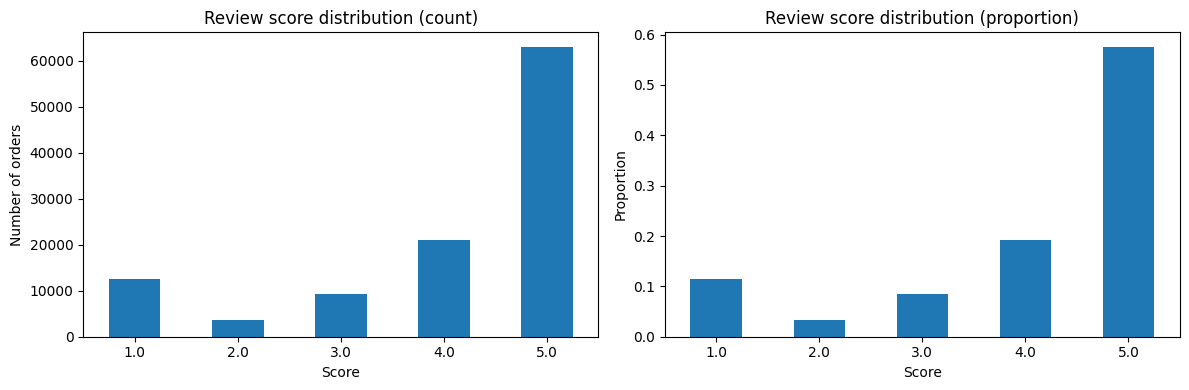

Bad review rate     (score <= 2): 14.8%
Neutral review rate (score == 3): 8.4%
Good review rate    (score >= 4): 76.8%
Orders with no review (NaN):      827 (0.8%)


In [5]:
review = base['review_score'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

review.value_counts().sort_index().plot.bar(ax=axes[0], rot=0)
axes[0].set_title('Review score distribution (count)')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Number of orders')

review.value_counts(normalize=True).sort_index().plot.bar(ax=axes[1], rot=0)
axes[1].set_title('Review score distribution (proportion)')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Proportion')

plt.tight_layout()
plt.show()

print(f"Bad review rate     (score <= 2): {(review <= 2).mean():.1%}")
print(f"Neutral review rate (score == 3): {(review == 3).mean():.1%}")
print(f"Good review rate    (score >= 4): {(review >= 4).mean():.1%}")
print(f"Orders with no review (NaN):      {base['review_score'].isna().sum()} ({base['review_score'].isna().mean():.1%})")

### 4. Delivery days distribution

Days from order placement to actual delivery. Check: median and tail, any negatives (data quality issue),
and the late delivery rate (actual > promised) — this is the raw signal behind the `late_delivery_rate` feature.

count    110189.000000
mean         12.472246
std           9.445346
min           0.533414
25%           6.736192
50%          10.184201
75%          15.540810
90%          22.920329
95%          29.056708
99%          45.806068
max         209.628611
Name: delivery_days, dtype: float64


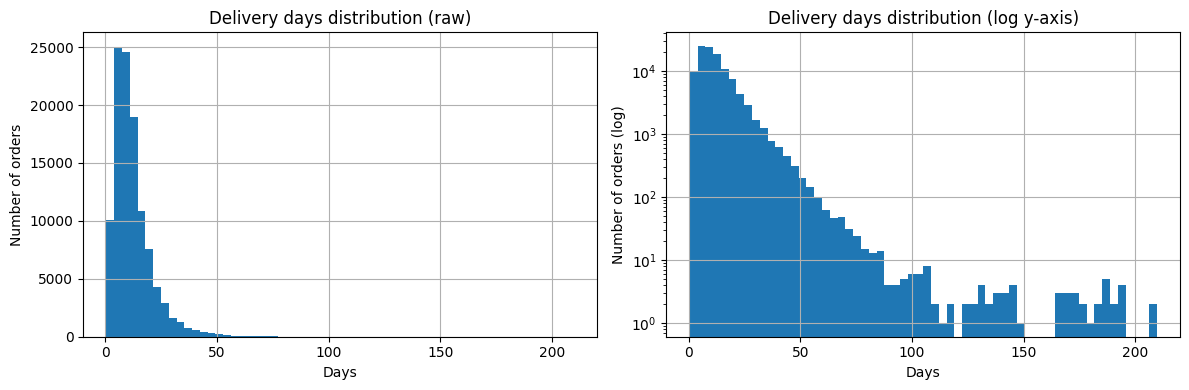


Negative delivery days (<0): 0
Very long delivery (>60d):   333 (0.3%)
Late delivery rate:           7.9%


In [6]:
delivery = base['delivery_days'].dropna()
print(delivery.describe(percentiles=[.25, .5, .75, .9, .95, .99]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

delivery.hist(bins=60, ax=axes[0])
axes[0].set_title('Delivery days distribution (raw)')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Number of orders')

delivery.hist(bins=60, log=True, ax=axes[1])
axes[1].set_title('Delivery days distribution (log y-axis)')
axes[1].set_xlabel('Days')
axes[1].set_ylabel('Number of orders (log)')

plt.tight_layout()
plt.show()


print(f"\nNegative delivery days (<0): {(delivery < 0).sum()}")
print(f"Very long delivery (>60d):   {(delivery > 60).sum()} ({(delivery > 60).mean():.1%})")
print(f"Late delivery rate:           {base['late_delivery'].mean():.1%}")

## TODO 2 — Build the label and inspect it
Use `app.features.build.split_windows` + `app.data.labels.label_underperforming`
(once implemented) to create the target, then check: class balance overall and the
underperformance rate *by category*. Is the within-category definition behaving as
intended?

### Step 1 — Split into feature / outcome windows

`split_windows` cuts `base` at the `train_end` date. The label is computed from
the **outcome window only** (post-cutoff orders) — using the full history here would
be target leakage.

In [7]:
from app.features.build import split_windows
from app.data.labels import label_underperforming
from app.config import get_params

params = get_params()
as_of      = pd.Timestamp(params["split"]["train_end"])
quantile   = params["target"]["underperformance_quantile"]
min_orders = params["target"]["min_orders_for_label"]

_, outcome_events = split_windows(base, as_of=as_of, horizon_days=180)

print(f"as_of date:     {as_of.date()}")
print(f"Feature window: {base[base['order_purchase_timestamp'] <= as_of].shape[0]:,} order-items")
print(f"Outcome window: {outcome_events.shape[0]:,} order-items")

as_of date:     2018-03-31
Feature window: 73,255 order-items
Outcome window: 36,942 order-items


In [8]:
outcome_events

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,review_score,product_category_name_english,delivery_days,late_delivery
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,480.0,1.0,200.0,16.0,10.0,15.0,4.0,perfumery,6.147269,0
7,000576fe39319847cbb9d288c5617fa6,1,557d850972a7d6f792fd18ae1400d9b6,5996cddab893a4652a15592fb58ab8db,2018-07-10 12:30:45,810.00,70.75,9ed5e522dd9dd85b4af4a077526d8117,delivered,2018-07-04 12:08:27,...,1310.0,3.0,13805.0,35.0,75.0,45.0,5.0,garden_tools,5.080324,0
9,0005f50442cb953dcd1d21e1fb923495,1,4535b0e1091c278dfd193e5a1d63b39f,ba143b05f0110f0dc71ad71b4466ce92,2018-07-06 14:10:56,53.99,11.40,351d3cb2cee3c7fd0af6616c82df21d3,delivered,2018-07-02 13:59:39,...,1192.0,1.0,850.0,29.0,3.0,21.0,4.0,books_technical,2.145046,0
11,00063b381e2406b52ad429470734ebd5,1,f177554ea93259a5b282f24e33f65ab6,8602a61d680a10a82cceeeda0d99ea3d,2018-07-31 17:30:39,45.00,12.98,6a899e55865de6549a58d2c6845e5604,delivered,2018-07-27 17:21:27,...,60.0,1.0,200.0,16.0,16.0,11.0,5.0,fashion_bags_accessories,10.857928,1
12,0006ec9db01a64e59a68b2c340bf65a7,1,99a4788cb24856965c36a24e339b6058,4a3ca9315b744ce9f8e9374361493884,2018-07-26 17:24:20,74.00,23.32,5d178120c29c61748ea95bac23cb8f25,delivered,2018-07-24 17:04:17,...,245.0,1.0,1383.0,50.0,10.0,40.0,5.0,bed_bath_table,6.333310,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110180,fff8286f77788ab8b55b2e5747fa7dd8,1,a2da86fa759178e9e58e54aa1a144e59,ea8482cd71df3c1969d7b9473ff13abc,2018-07-05 22:31:13,24.99,15.28,e79f494063c25f5c673222d8a2cc6f47,delivered,2018-07-03 21:53:22,...,777.0,5.0,350.0,17.0,4.0,12.0,4.0,telephony,2.707153,0
110191,fffbee3b5462987e66fb49b1c5411df2,1,6f0169f259bb0ff432bfff7d829b9946,213b25e6f54661939f11710a6fddb871,2018-06-28 09:58:03,119.85,20.03,11a0e041ea6e7e21856d2689b64e7f3a,delivered,2018-06-19 09:27:48,...,918.0,6.0,1050.0,16.0,20.0,16.0,5.0,home_construction,16.349537,0
110192,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,b51593916b4b8e0d6f66f2ae24f2673d,delivered,2018-04-23 13:57:06,...,1002.0,3.0,10150.0,89.0,15.0,40.0,5.0,housewares,17.374699,0
110193,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,84c5d4fbaf120aae381fad077416eaa0,delivered,2018-07-14 10:26:46,...,232.0,1.0,8950.0,45.0,26.0,38.0,5.0,computers_accessories,9.420243,0


### Step 2 — Build the label

`label_underperforming` aggregates outcome_events to product level and flags the
bottom `quantile` of revenue **within each category**.

In [9]:
labels = label_underperforming(
    outcome_events,
    quantile=quantile,
    min_orders=min_orders,
)

print(f"Products with a label: {len(labels):,}")
print(f"(excluded by min_orders={min_orders}: products with too few outcome-window orders have no label)\n")
labels.head()

Products with a label: 1,449
(excluded by min_orders=5: products with too few outcome-window orders have no label)



,product_id,category,revenue,n_orders,is_underperforming
0,00878d953636afec00d3e85d55a12e7f,beleza_saude,1000.00,10,0
1,008cff0e5792219fae03e570f980b330,esporte_lazer,2309.38,17,0
2,00fefaf41156bb4b0d850fb27da97897,esporte_lazer,69.95,5,1
3,0129d1e9b29d3fe6833cc922374cd252,consoles_games,66.08,5,1
4,013ee64977aaa6b2b25475095162e0e9,cama_mesa_banho,979.86,14,0


### Step 3 — Inspect class balance

Two checks: (1) overall positive rate, (2) per-category positive rate.
The within-category definition should produce ~25% underperformers per category.
Large deviations signal a data issue (e.g. a category where most products are filtered out by min_orders).

In [11]:
# --- Overall class balance ---
print("=== Overall ===")
print(labels["is_underperforming"].value_counts())
print(f"\nPositive rate: {labels['is_underperforming'].mean():.1%}  (target ~{quantile:.0%})")

# --- Per-category underperformance rate ---
print("\n=== By category (top 20 by product count) ===")
by_cat = (
    labels.groupby("category")
    .agg(n_products=("is_underperforming", "count"),
         underperforming_rate=("is_underperforming", "mean"))
    .sort_values("n_products", ascending=False)
    # .head(20)
)
by_cat["underperforming_rate"] = by_cat["underperforming_rate"].map("{:.1%}".format)
print(by_cat.to_string())

=== Overall ===
is_underperforming
0    1065
1     384
Name: count, dtype: int64

Positive rate: 26.5%  (target ~25%)

=== By category (top 20 by product count) ===
                                                n_products underperforming_rate
category                                                                       
beleza_saude                                           156                25.0%
cama_mesa_banho                                        140                25.0%
utilidades_domesticas                                  134                25.4%
esporte_lazer                                           93                25.8%
informatica_acessorios                                  87                25.3%
relogios_presentes                                      87                25.3%
moveis_decoracao                                        86                26.7%
telefonia                                               55                25.5%
eletronicos                        

## TODO 3 — Signal check
For 3–4 candidate features (e.g. `bad_review_rate`, `late_delivery_rate`,
`n_photos`, `price_vs_category_median`), compare their distributions for
underperforming vs healthy products. Which look promising? This is your feature
shortlist for Milestone 2 — and your talking points for the interview's
feature-engineering section.

In [83]:
feature_events, _ = split_windows(base, as_of=as_of, horizon_days=180)
print(f"Feature events: {feature_events.shape[0]:,} order-items")

print(feature_events.columns)

product_features = feature_events.groupby('product_id').agg(
    n_orders           = ("price", "count"),
    avg_price          = ("price", "mean"),
    category           = ("product_category_name", "first"),
    avg_delivery_days  = ("delivery_days", "mean"),
    weight_g           = ("product_weight_g",      "first"),
    freight_ratio = ("freight_value", lambda x: (x / feature_events.loc[x.index, "price"]).mean()),

    recency_days = ("order_purchase_timestamp",
                lambda x: (as_of - x.max()).days)  # 距最近一单多少天
)

cat_median = product_features.groupby('category')["avg_price"].transform("median")
product_features["price_vs_category_median"] = product_features["avg_price"] / cat_median

cat_median_orders = product_features.groupby("category")["n_orders"].transform("median")
product_features["n_orders_vs_category"] = product_features["n_orders"] / cat_median_orders


Feature events: 73,255 order-items
Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value', 'customer_id',
       'order_status', 'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'product_category_name',
       'product_name_lenght', 'product_description_lenght',
       'product_photos_qty', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm', 'review_score',
       'product_category_name_english', 'delivery_days', 'late_delivery'],
      dtype='str')


/var/folders/06/hmnjzdgn7vgcwblryw9g856c0000gn/T/ipykernel_33026/1974971028.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1][col].boxplot(groups, labels=["Healthy", "Underperform"], patch_artist=True,
/var/folders/06/hmnjzdgn7vgcwblryw9g856c0000gn/T/ipykernel_33026/1974971028.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1][col].boxplot(groups, labels=["Healthy", "Underperform"], patch_artist=True,
/var/folders/06/hmnjzdgn7vgcwblryw9g856c0000gn/T/ipykernel_33026/1974971028.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1][col].boxplot(groups, labels=["Healthy", "Underp

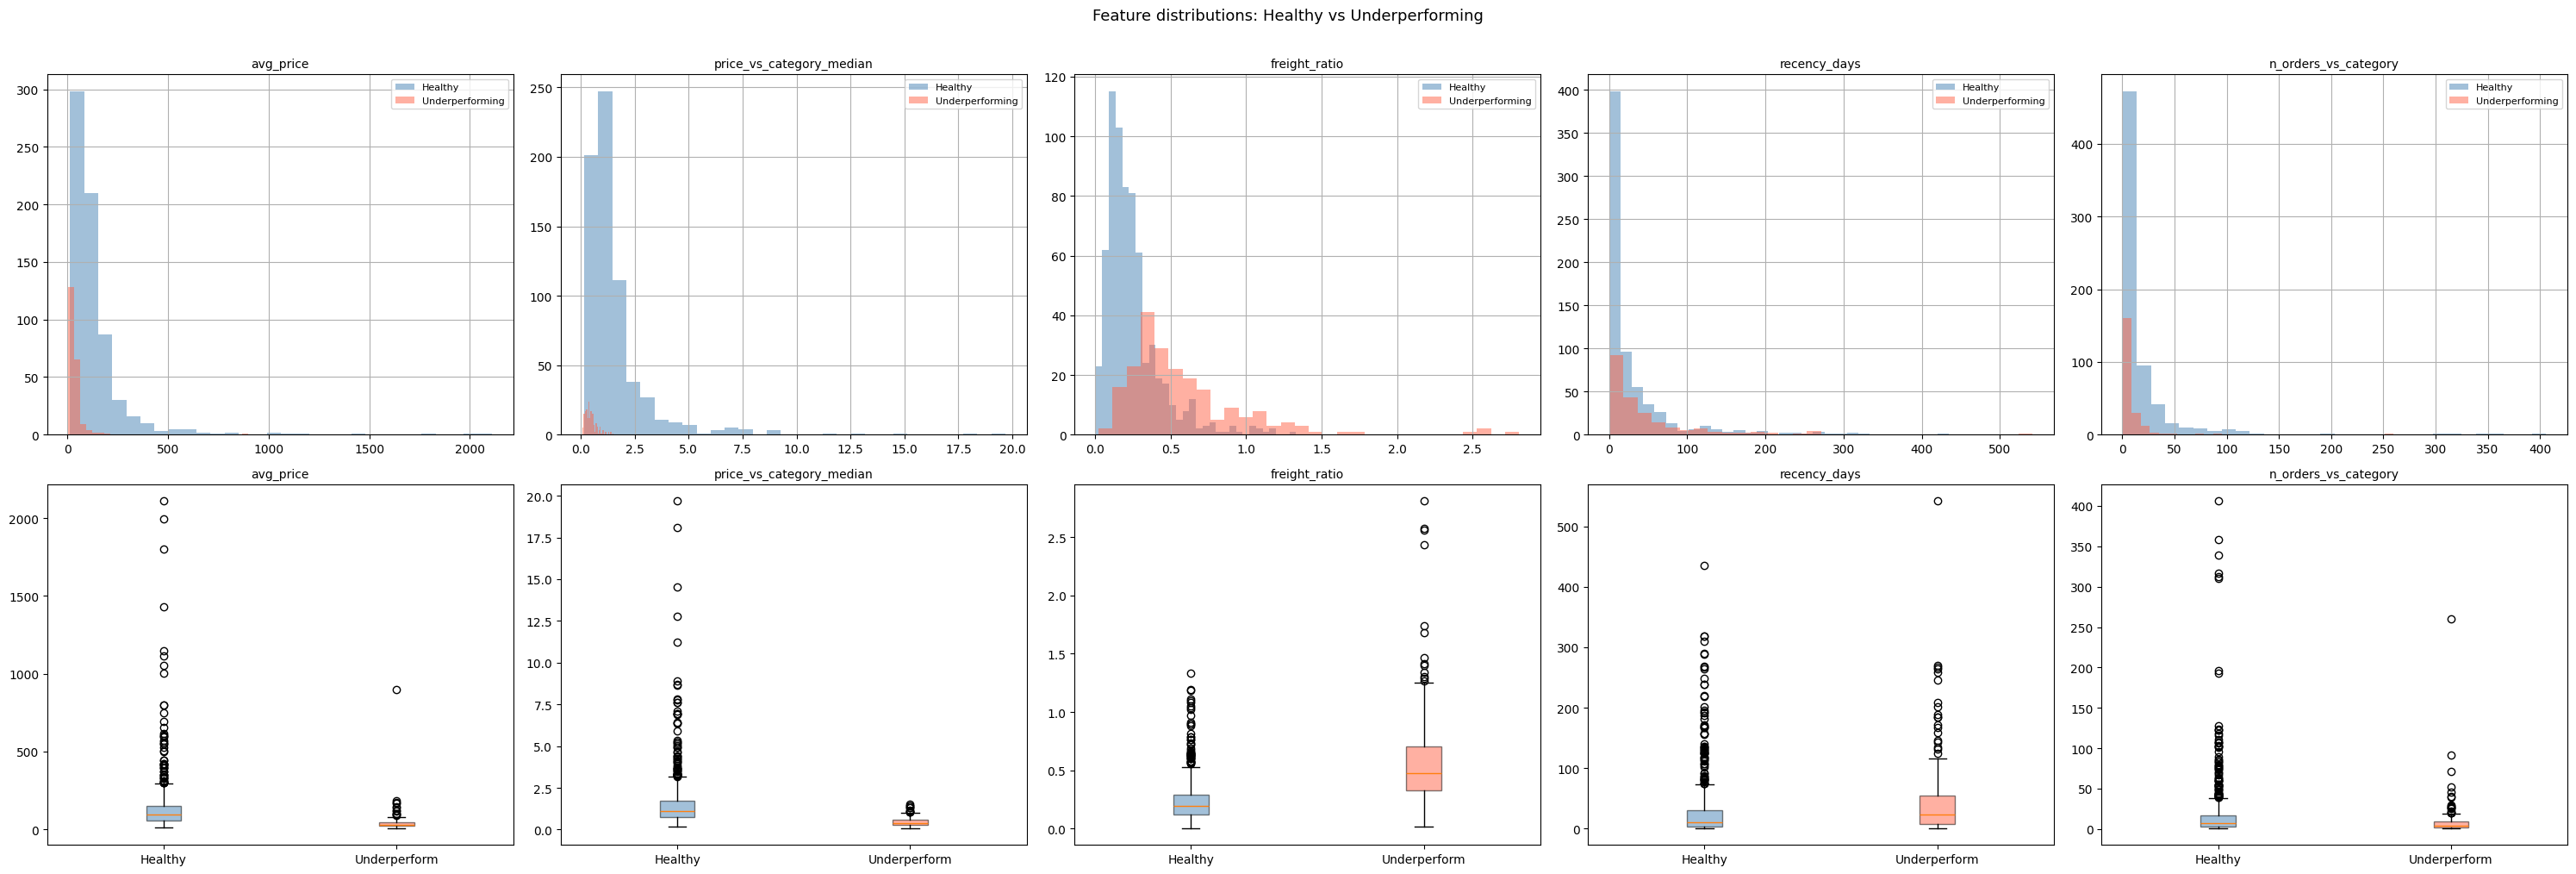

Feature                    P25 ratio  Median ratio  P75 ratio
--------------------------------------------------------------
avg_price                      0.36x         0.32x      0.29x
price_vs_category_median       0.36x         0.36x      0.33x
freight_ratio                  2.72x         2.45x      2.39x
recency_days                   2.67x         2.30x      1.74x
n_orders_vs_category           0.67x         0.64x      0.53x


In [85]:
product_features_with_label = product_features.merge(
    labels[["product_id", "is_underperforming"]],
    on="product_id", how="inner"
)

features_to_check = ["avg_price", "price_vs_category_median", "freight_ratio",
                     "recency_days", "n_orders_vs_category"]

fig, axes = plt.subplots(2, 5, figsize=(30, 10))

for col, feat in enumerate(features_to_check):
    # Top row: overlapping histogram
    for label, color, name in [(0, "steelblue", "Healthy"), (1, "tomato", "Underperforming")]:
        subset = product_features_with_label[
            product_features_with_label["is_underperforming"] == label
        ][feat].dropna()
        subset.hist(bins=30, alpha=0.5, ax=axes[0][col], color=color, label=name)
    axes[0][col].set_title(feat, fontsize=10)
    axes[0][col].legend(fontsize=8)

    # Bottom row: boxplot
    groups = [
        product_features_with_label[product_features_with_label["is_underperforming"] == g][feat].dropna()
        for g in [0, 1]
    ]
    bp = axes[1][col].boxplot(groups, labels=["Healthy", "Underperform"], patch_artist=True,
                              boxprops=dict(alpha=0.5))
    bp["boxes"][0].set_facecolor("steelblue")
    bp["boxes"][1].set_facecolor("tomato")
    axes[1][col].set_title(feat, fontsize=10)

plt.suptitle("Feature distributions: Healthy vs Underperforming", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

# Median comparison table
print(f"{'Feature':<25} {'P25 ratio':>10} {'Median ratio':>13} {'P75 ratio':>10}")
print("-" * 62)
for feat in features_to_check:
    healthy = product_features_with_label[
        product_features_with_label["is_underperforming"] == 0][feat].dropna()
    under   = product_features_with_label[
        product_features_with_label["is_underperforming"] == 1][feat].dropna()

    q25_h, med_h, q75_h = healthy.quantile([0.25, 0.5, 0.75])
    q25_u, med_u, q75_u = under.quantile([0.25, 0.5, 0.75])

    r25 = q25_u / q25_h if q25_h != 0 else float("nan")
    r50 = med_u / med_h  if med_h  != 0 else float("nan")
    r75 = q75_u / q75_h if q75_h != 0 else float("nan")

    print(f"{feat:<25} {r25:>9.2f}x {r50:>12.2f}x {r75:>9.2f}x")

## Takeaways

**1. Target: 26.5% positive rate, well-behaved in large categories**
1,449 products received a label after the `min_orders=5` filter. Overall positive rate is 26.5%,
close to the target quantile of 25%. Large categories (n ≥ 20) consistently produce ~25%
underperformers. Small categories (n ≤ 3) show 33–100% rates due to discrete quantile arithmetic

**2. Strongest signals: pricing and logistics cost structure**

The EDA reveals a coherent story about what "underperforming" means in this dataset:
**underperforming products are cheap, commodity-like items whose shipping cost is disproportionately
large relative to their price**, making the total cost unattractive to buyers.

Specific findings from the Olist data:

- `price_vs_category_median` (~0.36x, stable across P25/Median/P75): underperforming products are
  priced ~64% below their category peers at every quantile. The separation is uniform — not just
  in the tails — making this the most reliable single feature. 

- `freight_ratio` (2.45x median, 2.72x at P25): underperforming products spend ~47% of order
  value on freight vs. 19% for healthy products. The P25 ratio is the strongest (2.72x), meaning
  the phenomenon is most extreme for the cheapest underperforming products.

- `avg_price` (0.32x): underperforming products have a median price of R$29.99 vs. R$95 for
  healthy products — a 3x gap. Price alone is a strong signal, but `price_vs_category_median`
  is more informative because it controls for category-level pricing differences.

- `recency_days` (2.30x median, 2.67x at P25, 1.74x at P75): the tail is the story here.
  Products with very long recency (> 100 days since last order) are almost exclusively
  underperformers. But the boxplot shows healthy products' IQR is extremely narrow (most
  ordered within 10 days of as_of), while underperforming products have a much wider spread. This feature captures "product lifecycle stage."

- `n_orders_vs_category` (0.64x median, 0.53x at P75): underperforming products sell fewer
  orders than the typical product in their category. The separation grows at P75, meaning among
  the higher-volume products, healthy and underperforming diverge more.

**3. Quality signals are NOT predictive after Bayesian smoothing**
`bad_review_rate` and `late_delivery_rate` both converge to ratio ≈ 1.00x after smoothing.
This is a dataset-specific finding: Olist's underperformance label measures revenue rank within
category, not customer satisfaction. A product can have poor reviews and still outsell competitors
if it is priced right. Conversely, a well-reviewed product at 3× the category median price will
underperform on revenue. 

**4. Data quality issues for feature engineering**
- Cold-start is severe: the majority of Olist products have fewer than 5 orders in the feature
  window, making rate-based aggregates unreliable without Bayesian smoothing toward the category prior.
- `review_score` is missing for ~0.7% of orders (unreviewed orders); fill strategy needed.
- `product_category_name` is missing for ~1,500 order-items; needs a fallback / "unknown" category.
- Small categories (n ≤ 3 products with labels) produce 33–100% underperformance rates — unreliable
  and should be excluded from category-relative features or grouped into an "other" bucket.
